In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

# Resolve project root dynamically
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

warnings.filterwarnings('ignore')

import torch
import gpytorch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

from src.data.data_loader import load_cmapss_data
from src.models.train_svgp import train_svgp

In [2]:
# 1. Define paths and features 
DATA_DIR = PROJECT_ROOT / 'data' / 'raw'

# --- THE FIX: DROP CONSTANT SENSORS ---
# Rimuoviamo i sensori identificati nella EDA per sbloccare i gradienti del kernel
dead_sensors = ['s_1', 's_10', 's_18', 's_19']
features = [f's_{i}' for i in range(1, 22) if f's_{i}' not in dead_sensors]
num_features = len(features)
print(f"Using {num_features} informative features.")

# 2. Load Data
df_train = load_cmapss_data(str(DATA_DIR / 'train_FD001.txt'))
df_test = load_cmapss_data(str(DATA_DIR / 'test_FD001.txt'), str(DATA_DIR / 'RUL_FD001.txt'))

# Piecewise Linear RUL Clipping
MAX_RUL = 125
df_train['RUL'] = df_train['RUL'].clip(upper=MAX_RUL)
df_test['RUL'] = df_test['RUL'].clip(upper=MAX_RUL)

# 3. Strict Normalization for FEATURES (X)
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(df_train[features].values)

# 4. Strict Normalization for TARGET (y)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(df_train['RUL'].values.reshape(-1, 1)).flatten()

# 5. Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)

# 6. Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

Using 17 informative features.


In [3]:
# Execute the SVGP training loop
# We use 100 inducing points to compress the dataset representation
model, likelihood = train_svgp(
    train_loader=train_loader, 
    num_features=num_features, 
    num_inducing=256, 
    epochs=100, 
    lr=0.01
)

--- Starting SVGP Training (100 Epochs) ---
Epoch 01/100 - Loss (Negative ELBO): 12.9067
Epoch 02/100 - Loss (Negative ELBO): 3.0191
Epoch 03/100 - Loss (Negative ELBO): 1.3338
Epoch 04/100 - Loss (Negative ELBO): 1.0062
Epoch 05/100 - Loss (Negative ELBO): 0.8923
Epoch 06/100 - Loss (Negative ELBO): 0.8296
Epoch 07/100 - Loss (Negative ELBO): 0.7861
Epoch 08/100 - Loss (Negative ELBO): 0.7554
Epoch 09/100 - Loss (Negative ELBO): 0.7262
Epoch 10/100 - Loss (Negative ELBO): 0.7066
Epoch 11/100 - Loss (Negative ELBO): 0.6903
Epoch 12/100 - Loss (Negative ELBO): 0.6724
Epoch 13/100 - Loss (Negative ELBO): 0.6594
Epoch 14/100 - Loss (Negative ELBO): 0.6530
Epoch 15/100 - Loss (Negative ELBO): 0.6438
Epoch 16/100 - Loss (Negative ELBO): 0.6364
Epoch 17/100 - Loss (Negative ELBO): 0.6297
Epoch 18/100 - Loss (Negative ELBO): 0.6256
Epoch 19/100 - Loss (Negative ELBO): 0.6221
Epoch 20/100 - Loss (Negative ELBO): 0.6191
Epoch 21/100 - Loss (Negative ELBO): 0.6164
Epoch 22/100 - Loss (Negative E

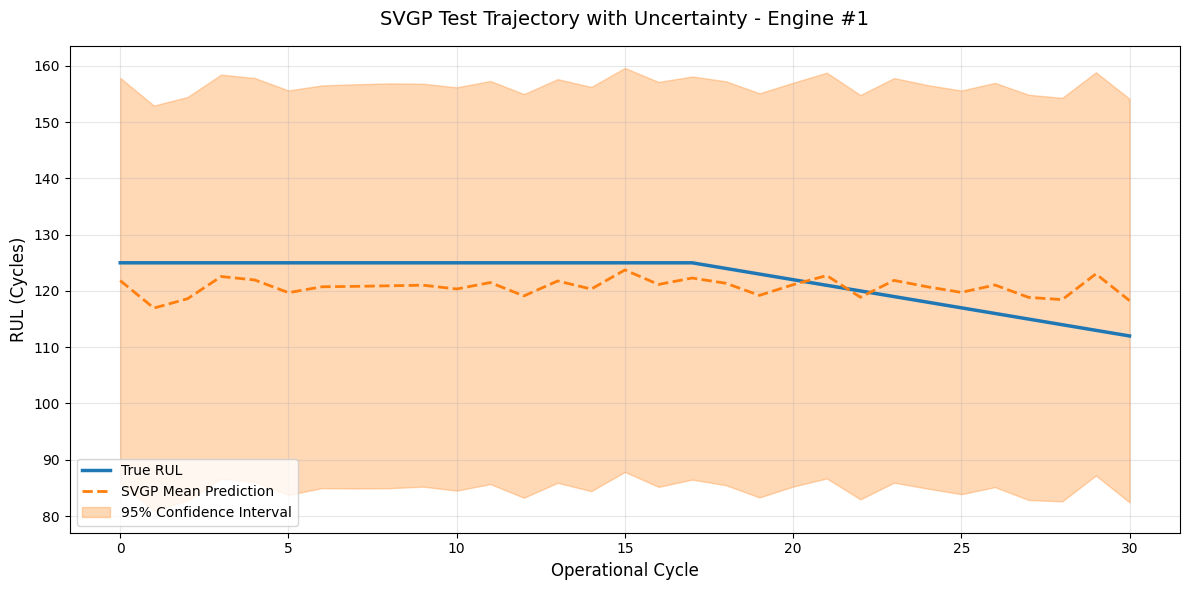

In [4]:
def plot_svgp_predictions_corrected(engine_id=1):
    model.eval()
    likelihood.eval()

    # Extract test data
    engine_data = df_test[df_test['unit_nr'] == engine_id]
    
    # Scale X using the X scaler
    X_test_scaled = scaler_x.transform(engine_data[features].values)
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_true = engine_data['RUL'].values

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        observed_pred = likelihood(model(X_test_tensor))
        
        # Extract mean and bounds in SCALED format
        mean_scaled = observed_pred.mean.numpy()
        lower_scaled, upper_scaled = observed_pred.confidence_region()
        lower_scaled = lower_scaled.numpy()
        upper_scaled = upper_scaled.numpy()

    # INVERSE TRANSFORM to get back to original RUL cycles
    mean = scaler_y.inverse_transform(mean_scaled.reshape(-1, 1)).flatten()
    lower = scaler_y.inverse_transform(lower_scaled.reshape(-1, 1)).flatten()
    upper = scaler_y.inverse_transform(upper_scaled.reshape(-1, 1)).flatten()

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(y_true, label="True RUL", color='#1f77b4', linewidth=2.5)
    
    # SVGP Mean and Uncertainty Bands
    plt.plot(mean, label="SVGP Mean Prediction", color='#ff7f0e', linestyle='--', linewidth=2)
    plt.fill_between(range(len(mean)), lower, upper, alpha=0.3, color='#ff7f0e', label="95% Confidence Interval")

    plt.title(f"SVGP Test Trajectory with Uncertainty - Engine #{engine_id}", fontsize=14, pad=15)
    plt.xlabel("Operational Cycle", fontsize=12)
    plt.ylabel("RUL (Cycles)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_svgp_predictions_corrected(engine_id=1)

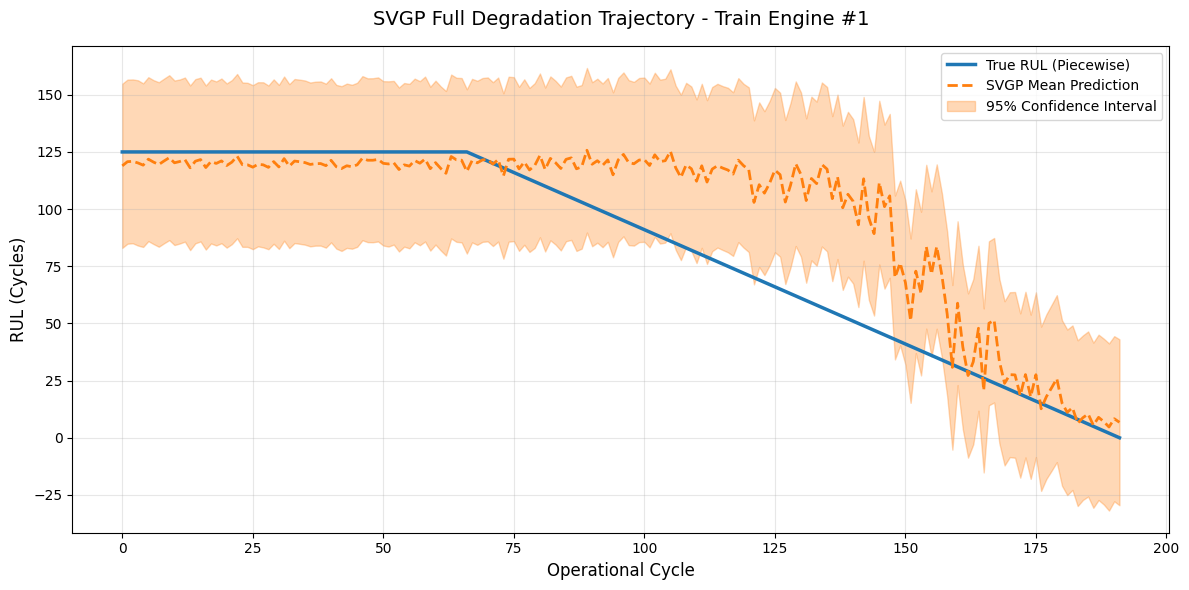

In [ ]:
def plot_svgp_full_degradation(engine_id=1):
    model.eval()
    likelihood.eval()

    # Engine data from TRAIN SET to see the full degradation trajectory
    engine_data = df_train[df_train['unit_nr'] == engine_id]
    
    # Scale X using the X scaler
    X_scaled = scaler_x.transform(engine_data[features].values)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    y_true = engine_data['RUL'].values

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        observed_pred = likelihood(model(X_tensor))
        
        # Extract mean and bounds in SCALED format
        mean_scaled = observed_pred.mean.numpy()
        lower_scaled, upper_scaled = observed_pred.confidence_region()
        
    # INVERSE TRANSFORM to get back to original RUL cycles
    mean = scaler_y.inverse_transform(mean_scaled.reshape(-1, 1)).flatten()
    lower = scaler_y.inverse_transform(lower_scaled.reshape(-1, 1)).flatten()
    upper = scaler_y.inverse_transform(upper_scaled.reshape(-1, 1)).flatten()

    # Plotting
    plt.figure(figsize=(12, 6))
    
    # True RUL (clipped at 125)
    plt.plot(y_true, label="True RUL (Piecewise)", color='#1f77b4', linewidth=2.5)
    
    # SVGP Prediction
    plt.plot(mean, label="SVGP Mean Prediction", color='#ff7f0e', linestyle='--', linewidth=2)
    plt.fill_between(range(len(mean)), lower, upper, alpha=0.3, color='#ff7f0e', label="95% Confidence Interval")

    plt.title(f"SVGP Full Degradation Trajectory - Train Engine #{engine_id}", fontsize=14, pad=15)
    plt.xlabel("Operational Cycle", fontsize=12)
    plt.ylabel("RUL (Cycles)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot on engine 1 to see the full degradation trajectory
plot_svgp_full_degradation(engine_id=1)